In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import graph_style as gs
import fig_helper as fh
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

gs.set_graph_style(246/510)

In [10]:
def plot_data_fit(ax, df, m, popt):
    x_min = 1
    model_func = m.model
    x_max = max(df["Clifford Length"]) * 2
    if m.name == "GT" or m.name == "PTM":
        reshape_fac = 4
        ax.hlines(0.25, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.5, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)
        ax.hlines(0.333, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)

        ax.errorbar(df["Clifford Length"], df["P00"], yerr=df["P00 Std"], fmt="^", label="$\\mathcal{P}_{SS}$", color=gs.get_color(1), alpha=0.8)
        ax.errorbar(df["Clifford Length"], df["P11"], yerr=df["P11 Std"], fmt="^", label="$\\mathcal{P}_{DD}$", color="#017517", alpha=0.8)
        P0110 = [a+b for a, b in zip(df["P01"], df["P10"])]
        P0110_std = [np.sqrt(a**2 + b**2) for a, b in zip(df["P01 Std"], df["P10 Std"])]
        ax.errorbar(df["Clifford Length"], P0110, yerr=P0110_std, fmt="^", label="$\\mathcal{P}_{SD}+\\mathcal{P}_{DS}$", color=gs.get_color(3), alpha=0.8)
        x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color=gs.get_color(1), alpha=gs.get_alpha())
        ax.plot(x_fit, P_fit[3], color="#017517", alpha=gs.get_alpha())
        P0110_fit = P_fit[1] + P_fit[2]
        ax.plot(x_fit, P0110_fit, color=gs.get_color(3), alpha=gs.get_alpha())
        ax.set_ylabel("Populations")
        ax.legend(loc="upper center")
        ax.set_ylim(-0.05, 1.0)


    elif m.name == "GTRed":
        reshape_fac = 3
        ax.hlines(1/3, x_min, x_max, color=gs.get_color(2), linestyle="--", alpha=0.8)
        ax.hlines(0, x_min, x_max, color=gs.get_color(5), linestyle="--", alpha=0.8)

        pops = [df["P00"], df["P01"], df["P10"], df["P11"]]
        errs = [df["P00 Std"], df["P01 Std"], df["P10 Std"], df["P11 Std"]]
        pops, errs = m.convert_pops(pops, errs)
        Par, P1, P2 = pops
        Par_err, P1_err, P2_err = errs
        ax.errorbar(df["Clifford Length"], Par, yerr=Par_err, fmt="^", label="$\\Pi$", color="black")
       
        x_fit = np.logspace(np.log10(x_min), np.log10(x_max), 100)        
        P_fit = model_func(x_fit, *popt).reshape(reshape_fac, -1)
        ax.plot(x_fit, P_fit[0], color="black", alpha=gs.get_alpha())
        ax.set_ylabel("Parity, $\\Pi$")
        ax.set_ylim(-0.05, 0.9)
        ax.set_yticks([0, 1/3, 2/3])
        ax.set_yticklabels(["0", r"$\frac{1}{3}$", r"$\frac{2}{3}$"])

    ax.set_xlim(x_min, x_max)
    
    ax.set_xscale("log")
    # place legend in upper right corner


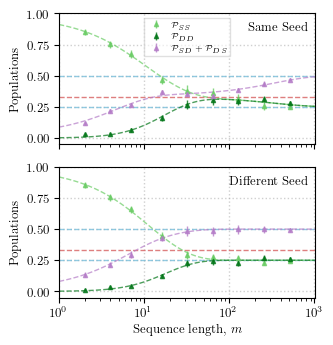

In [14]:
# Time dependent errors
"""
Seed 7777: RID 92942, 92943
Seed 7776: RID 92944

Plot 1: 92943_92943_ions01
Plot 2: 92943_92944_ions00 Diff Seed
Plot 3: 92942_92943_ions00 Same Seed
"""
#m = fh.PTMModel()
m = fh.GTModel()
fig_width = (246/510)*gs.get_fig_width()
fig_height = (3/4)*gs.get_fig_width()*2/3
fig, (ax3, ax2) = plt.subplots(2, 1, figsize=(fig_width, fig_height), sharex=True)

#gs.place_letter(fig, "c")
date = "2026-02-03"
sim_outcomes = [0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, ]

rids_arr = [92943, 92944]

# times = [0,0]
# ions = [0, 1]
# df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
# plot_data_fit(ax1, df, m.model, popt)

times = [0,1]
ions = [0, 0]
df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
plot_data_fit(ax2, df, m, popt)

rids_arr = [92943, 92942]
times = [0,1]
ions = [0, 0]
df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
plot_data_fit(ax3, df, m, popt)

ax2.legend().remove()
#ax3.legend().remove()
# add label to top right of each subplot
#ax1.text(0.97, 0.93, "Same Time", transform=ax1.transAxes, ha="right", va="top")
ax2.text(0.97, 0.93, "Different Seed", transform=ax2.transAxes, ha="right", va="top")
ax3.text(0.97, 0.93, "Same Seed", transform=ax3.transAxes, ha="right", va="top")

ax2.set_xlabel("Sequence length, $m$")
f_path = "..\\pdf_figure\\f5_time_dependent.pdf"
fig.savefig(f_path)

C:\Users\webbd\AppData\Local\Temp\ipykernel_22336\2469341967.py:8: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.savefig(f_path)
c:\Users\webbd\.conda\envs\atomic\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.canvas.print_figure(bytes_io, **kw)


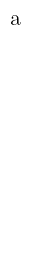

In [51]:
fig_width = 4*gs.get_margin()
fig_height = (1/2)*gs.get_fig_width() - gs.get_margin()
fig, ax1 = plt.subplots(1, 1, figsize=(fig_width, fig_height))
ax1.axis("off")

gs.place_letter(fig, "a")
f_path = "..\\pdf_figure\\f3_circuit_letter.pdf"
plt.savefig(f_path)

$\theta_{\mathrm{com}}$: 0.6652 ± 0.0285
$\theta_{\mathrm{diff}}$: 0.0396 ± 0.0065
Angle between axes ($\theta_{\mathrm{ax}}$): 1.4137 ± 0.5559
$\epsilon_{\mathrm{SP}}$: 0.0010 ± 0.0171
$\theta_{\mathrm{com}}$: 0.5642 ± 0.0370
$\theta_{\mathrm{diff}}$: 0.3034 ± 0.0438
Angle between axes ($\theta_{\mathrm{ax}}$): 1.7115 ± 0.0643
$\epsilon_{\mathrm{SP}}$: 0.0010 ± 0.0219
$\theta_{\mathrm{com}}$: 0.6511 ± 0.0291
$\theta_{\mathrm{diff}}$: 0.0560 ± 0.0091
Angle between axes ($\theta_{\mathrm{ax}}$): 1.8076 ± 0.3951
$\epsilon_{\mathrm{SP}}$: 0.0010 ± 0.0183


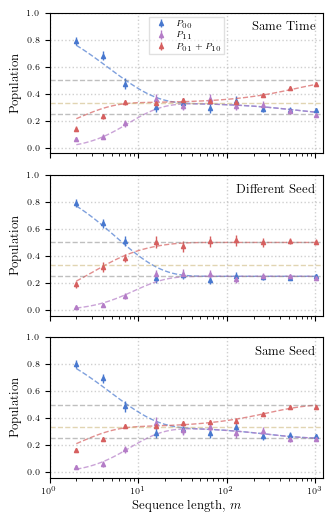

In [8]:
# Time dependent errors
"""
date = "2026-02-19"

rids_arr = [94060  , 94062]
#rids_arr = [94061  , 94062]
Plot 1: 94060_94060_ions01
Plot 2: 94060_94062_ions00 Diff Seed
Plot 3: 94060_94061_ions00 Same Seed
"""
#m = fh.PTMModel()
def print_fit_params(popt, pcov, m):
    param_names = [m.p1_name, m.p2_name, m.p3_name, m.p4_name]
    for i in range(len(popt)):
        param = popt[i]
        param_err = np.sqrt(pcov[i][i])
        print(f"{param_names[i]}: {param:.4f} ± {param_err:.4f}")

m = fh.GTModel()
fig_width = (246/510)*gs.get_fig_width()
fig_height = (3/4)*gs.get_fig_width()
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(fig_width, fig_height), sharex=True)


date = "2026-02-19"
sim_outcomes = [1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 0.0, 1.0, ]

rids_arr = [94060, 94062]
times = [0,0]
ions = [0, 1]
df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
plot_data_fit(ax1, df, m.model, popt)
print_fit_params(popt, pcov, m)

times = [0,1]
ions = [0, 0]
df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
plot_data_fit(ax2, df, m.model, popt)
print_fit_params(popt, pcov, m)

rids_arr = [94060, 94061]
times = [0,1]
ions = [0, 0]
df, popt, pcov = m.rb_time_to_fits(date, rids_arr, times, ions, sim_outcomes)
plot_data_fit(ax3, df, m.model, popt)
print_fit_params(popt, pcov, m)

ax2.legend().remove()
ax3.legend().remove()
# add label to top right of each subplot
ax1.text(0.97, 0.93, "Same Time", transform=ax1.transAxes, ha="right", va="top")
ax2.text(0.97, 0.93, "Different Seed", transform=ax2.transAxes, ha="right", va="top")
ax3.text(0.97, 0.93, "Same Seed", transform=ax3.transAxes, ha="right", va="top")

ax3.set_xlabel("Sequence length, $m$")
f_path = "..\\pdf_figure\\f4_time_dependent.pdf"
fig.savefig(f_path)